# GAN Based Synthetic Image Generation using MNIST

Name: Rohith John  
Roll No: 24BAD100


# PART A: DATASET PREPARATION AND IMAGE PREPROCESSING

In [23]:
# Libraries and reproducibility

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, Model

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))


TensorFlow version: 2.20.0
GPU devices: []


## Dataset Loading from Kaggle

In [24]:
# Automatically find an MNIST training CSV in Kaggle Input.
# No local download is required.

csv_candidates = []

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        if file.lower().endswith(".csv"):
            csv_candidates.append(os.path.join(root, file))

print("CSV files found in /kaggle/input:")
for path in csv_candidates:
    print(path)

# Find a CSV that looks like an MNIST training file.
TRAIN_CSV = None

for path in csv_candidates:
    base = os.path.basename(path).lower()
    if "mnist" in base and "train" in base:
        TRAIN_CSV = path
        break

if TRAIN_CSV is None:
    for path in csv_candidates:
        base = os.path.basename(path).lower()
        if base == "train.csv" or "train" in base:
            TRAIN_CSV = path
            break

if TRAIN_CSV is None:
    raise FileNotFoundError(
        "No MNIST training CSV was found. Attach an MNIST CSV dataset "
        "from Kaggle's Input panel and run all cells again."
    )

print("\nSelected training file:")
print(TRAIN_CSV)

mnist_df = pd.read_csv(TRAIN_CSV)

print("\nDataset shape:", mnist_df.shape)
display(mnist_df.head())


CSV files found in /kaggle/input:
/kaggle/input/datasets/oddrationale/mnist-in-csv/mnist_test.csv
/kaggle/input/datasets/oddrationale/mnist-in-csv/mnist_train.csv

Selected training file:
/kaggle/input/datasets/oddrationale/mnist-in-csv/mnist_train.csv

Dataset shape: (60000, 785)


,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Dataset Exploration

In [25]:
# Identify the label column and inspect the dataset

label_candidates = ["label", "Label", "target", "Target", "class", "Class"]

label_column = next(
    (col for col in label_candidates if col in mnist_df.columns),
    mnist_df.columns[0]
)

print("Label column:", label_column)
print("Number of images:", len(mnist_df))
print("Number of columns:", len(mnist_df.columns))

print("\nLabel distribution:")
print(mnist_df[label_column].value_counts().sort_index())


Label column: label
Number of images: 60000
Number of columns: 785

Label distribution:
label
0    5923
1    6742
2    5958
3    6131
4    5842
5    5421
6    5918
7    6265
8    5851
9    5949
Name: count, dtype: int64


In [26]:
# Prepare pixel values and labels

labels = mnist_df[label_column].to_numpy()

pixel_columns = [col for col in mnist_df.columns if col != label_column]
X = mnist_df[pixel_columns].to_numpy(dtype=np.float32)

if X.shape[1] != 784:
    raise ValueError(
        f"MNIST should contain 784 pixel columns, but found {X.shape[1]}."
    )

X_images = X.reshape(-1, 28, 28, 1)

# Normalize pixels from [0, 255] to [-1, 1]
X_images = (X_images - 127.5) / 127.5

print("Image data shape:", X_images.shape)
print("Pixel range:", float(X_images.min()), "to", float(X_images.max()))


Image data shape: (60000, 28, 28, 1)
Pixel range: -1.0 to 1.0


## Sample Images

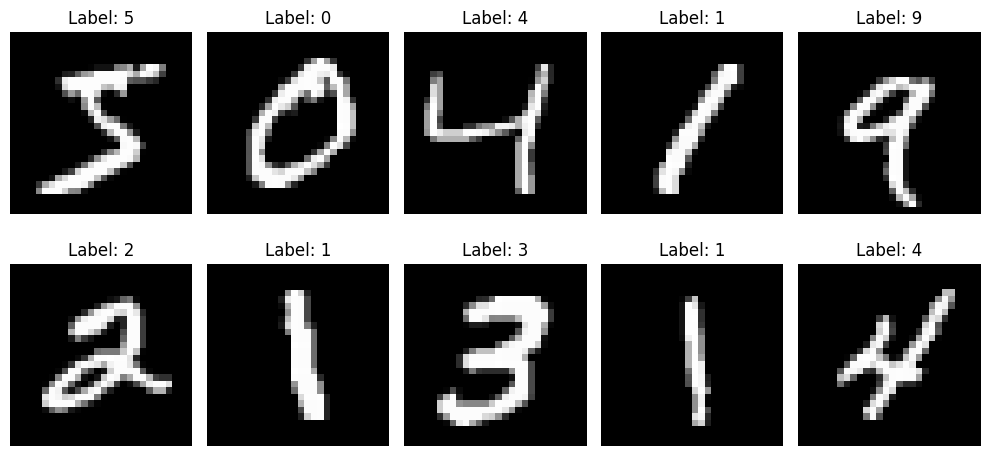

In [27]:
# Display real MNIST images

plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_images[i, :, :, 0] * 0.5 + 0.5, cmap="gray")
    plt.title(f"Label: {labels[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()


## TensorFlow Data Pipeline

In [28]:
# Use a practical subset for fast Run All execution.
# Change MAX_TRAIN_IMAGES to len(X_images) when a full training run is required.

MAX_TRAIN_IMAGES = min(len(X_images), 20000)
BATCH_SIZE = 128

X_train_gan = X_images[:MAX_TRAIN_IMAGES]

train_dataset = (
    tf.data.Dataset.from_tensor_slices(X_train_gan)
    .shuffle(
        buffer_size=min(MAX_TRAIN_IMAGES, 10000),
        seed=SEED,
        reshuffle_each_iteration=True
    )
    .batch(BATCH_SIZE, drop_remainder=True)
    .prefetch(tf.data.AUTOTUNE)
)

steps_per_epoch = MAX_TRAIN_IMAGES // BATCH_SIZE

print("Images used for GAN training:", MAX_TRAIN_IMAGES)
print("Batch size:", BATCH_SIZE)
print("Steps per epoch:", steps_per_epoch)


Images used for GAN training: 20000
Batch size: 128
Steps per epoch: 156


# PART B: IMPLEMENTING THE GENERATOR

## Generator Architecture

In [29]:
LATENT_DIM = 100

generator = tf.keras.Sequential([
    layers.Input(shape=(LATENT_DIM,)),

    layers.Dense(7 * 7 * 128, use_bias=False),
    layers.BatchNormalization(),
    layers.LeakyReLU(),

    layers.Reshape((7, 7, 128)),

    layers.Conv2DTranspose(
        64,
        kernel_size=5,
        strides=2,
        padding="same",
        use_bias=False
    ),
    layers.BatchNormalization(),
    layers.LeakyReLU(),

    layers.Conv2DTranspose(
        1,
        kernel_size=5,
        strides=2,
        padding="same",
        activation="tanh"
    )
], name="Generator")

generator.summary()


Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 6272)           │       627,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 6272)           │        25,088 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 14, 14, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 28, 28, 1)      │         1,601 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 858,945 (3.28 MB)

 Trainable params: 846,273 (3.23 MB)

 Non-trainable params: 12,672 (49.50 KB)

## Generated Image Before Training

Generated image shape: (1, 28, 28, 1)


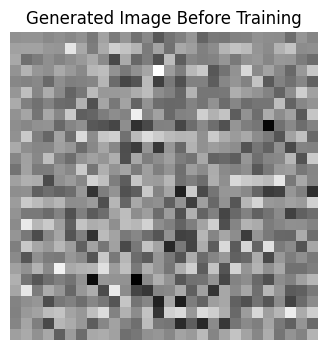

In [30]:
# Generate one image before training

noise = tf.random.normal([1, LATENT_DIM], seed=SEED)
generated_image = generator(noise, training=False)

print("Generated image shape:", generated_image.shape)

plt.figure(figsize=(4, 4))
plt.imshow(generated_image[0, :, :, 0] * 0.5 + 0.5, cmap="gray")
plt.title("Generated Image Before Training")
plt.axis("off")
plt.show()


# PART C: IMPLEMENTING THE DISCRIMINATOR AND GAN MODEL

## Discriminator Architecture

In [31]:
discriminator = tf.keras.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(
        64,
        kernel_size=5,
        strides=2,
        padding="same"
    ),
    layers.LeakyReLU(),
    layers.Dropout(0.3),

    layers.Conv2D(
        128,
        kernel_size=5,
        strides=2,
        padding="same"
    ),
    layers.LeakyReLU(),
    layers.Dropout(0.3),

    layers.Flatten(),
    layers.Dense(1)
], name="Discriminator")

discriminator.summary()


Model: "Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 7, 7, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_7 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,865 (831.50 KB)

 Trainable params: 212,865 (831.50 KB)

 Non-trainable params: 0 (0.00 B)

## Discriminator Compilation

In [32]:
# Binary cross-entropy is used for real/fake classification.

cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

discriminator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.0002,
    beta_1=0.5
)

generator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.0002,
    beta_1=0.5
)

# Compile the Discriminator as required for the experiment.
# The actual GAN training below uses a custom training loop.

discriminator.compile(
    optimizer=discriminator_optimizer,
    loss=cross_entropy
)

print("Discriminator compiled successfully.")
print("Loss: Binary Cross-Entropy")
print("Optimizer: Adam")


Discriminator compiled successfully.
Loss: Binary Cross-Entropy
Optimizer: Adam


## GAN Model

In [33]:
# Create the combined Generator + Discriminator model

gan_input = layers.Input(shape=(LATENT_DIM,), name="noise_input")
gan_output = discriminator(generator(gan_input))

gan_model = Model(
    gan_input,
    gan_output,
    name="GAN"
)

print("GAN model created successfully.")
gan_model.summary()


GAN model created successfully.


Model: "GAN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ noise_input (InputLayer)        │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Generator (Sequential)          │ (None, 28, 28, 1)      │       858,945 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Discriminator (Sequential)      │ (None, 1)              │       212,865 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,071,810 (4.09 MB)

 Trainable params: 1,059,138 (4.04 MB)

 Non-trainable params: 12,672 (49.50 KB)

# PART D: GAN TRAINING AND SYNTHETIC IMAGE GENERATION

## GAN Training Setup

In [34]:
# Training configuration

EPOCHS = 5
NUM_EXAMPLES_TO_GENERATE = 16

fixed_seed = tf.random.normal(
    [NUM_EXAMPLES_TO_GENERATE, LATENT_DIM],
    seed=SEED
)

generator_losses = []
discriminator_losses = []

print("Epochs:", EPOCHS)
print("Training images:", MAX_TRAIN_IMAGES)


Epochs: 5
Training images: 20000


## Loss Functions and Training Step

In [35]:
def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(
        tf.ones_like(real_output),
        real_output
    )

    fake_loss = cross_entropy(
        tf.zeros_like(fake_output),
        fake_output
    )

    return real_loss + fake_loss


def generator_loss(fake_output):
    return cross_entropy(
        tf.ones_like(fake_output),
        fake_output
    )


@tf.function(reduce_retracing=True)
def train_step(images):
    noise = tf.random.normal([
        tf.shape(images)[0],
        LATENT_DIM
    ])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gen_gradients = gen_tape.gradient(
        gen_loss,
        generator.trainable_variables
    )

    disc_gradients = disc_tape.gradient(
        disc_loss,
        discriminator.trainable_variables
    )

    generator_optimizer.apply_gradients(
        zip(gen_gradients, generator.trainable_variables)
    )

    discriminator_optimizer.apply_gradients(
        zip(disc_gradients, discriminator.trainable_variables)
    )

    return gen_loss, disc_loss


print("Training step ready.")


Training step ready.


## Generated Images During Training

In [36]:
def show_generated_images(model, test_input, title):
    predictions = model(test_input, training=False)

    plt.figure(figsize=(8, 8))

    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i + 1)
        plt.imshow(
            predictions[i, :, :, 0] * 0.5 + 0.5,
            cmap="gray"
        )
        plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


## Train the GAN

Epoch 1/5 | Steps: 156 | Generator Loss: 0.8504 | Discriminator Loss: 0.9948


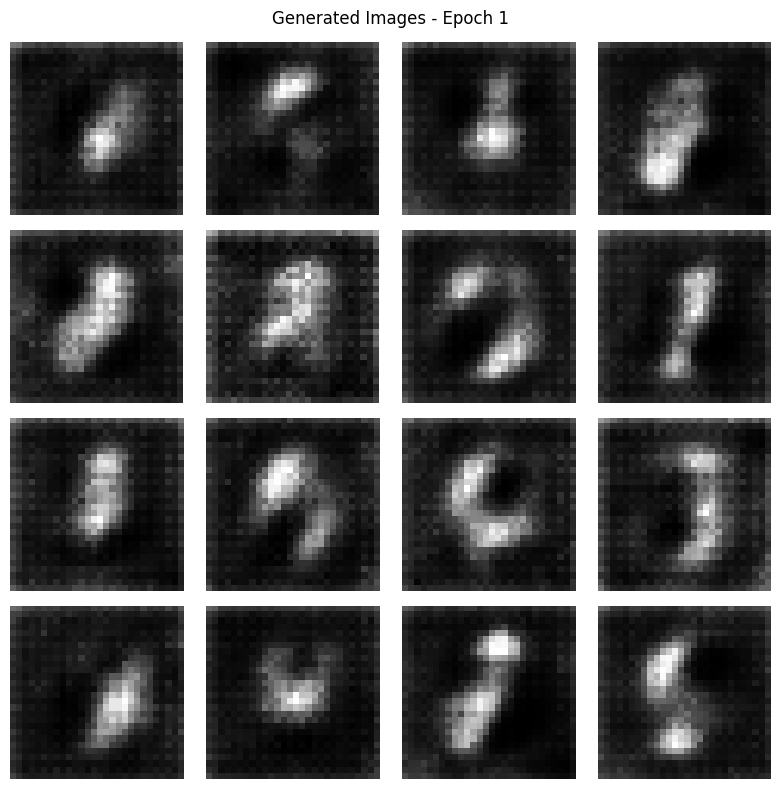

Epoch 2/5 | Steps: 156 | Generator Loss: 0.8424 | Discriminator Loss: 1.2222


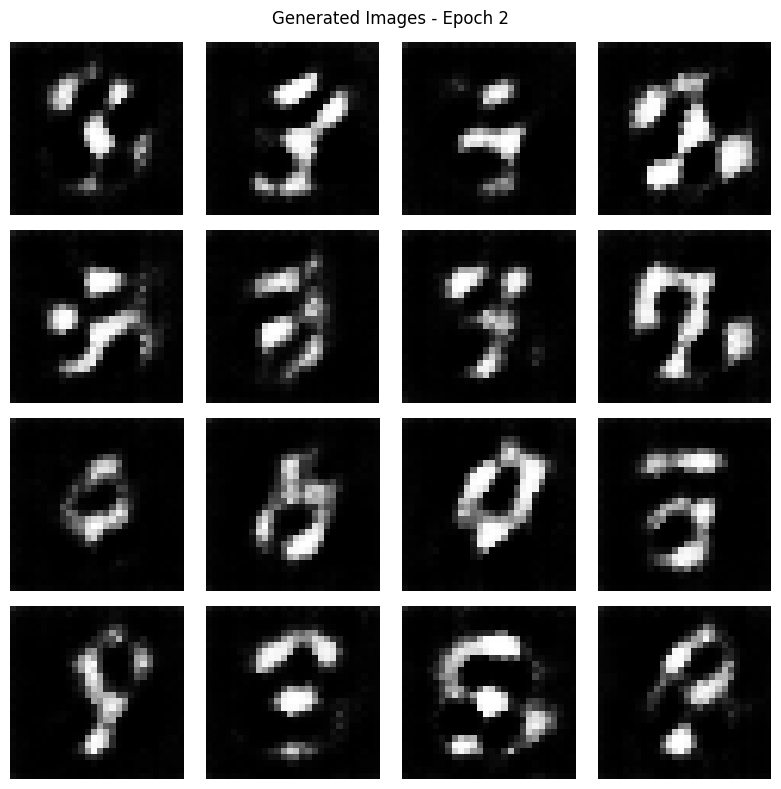

Epoch 3/5 | Steps: 156 | Generator Loss: 0.7867 | Discriminator Loss: 1.2921
Epoch 4/5 | Steps: 156 | Generator Loss: 0.8011 | Discriminator Loss: 1.2992


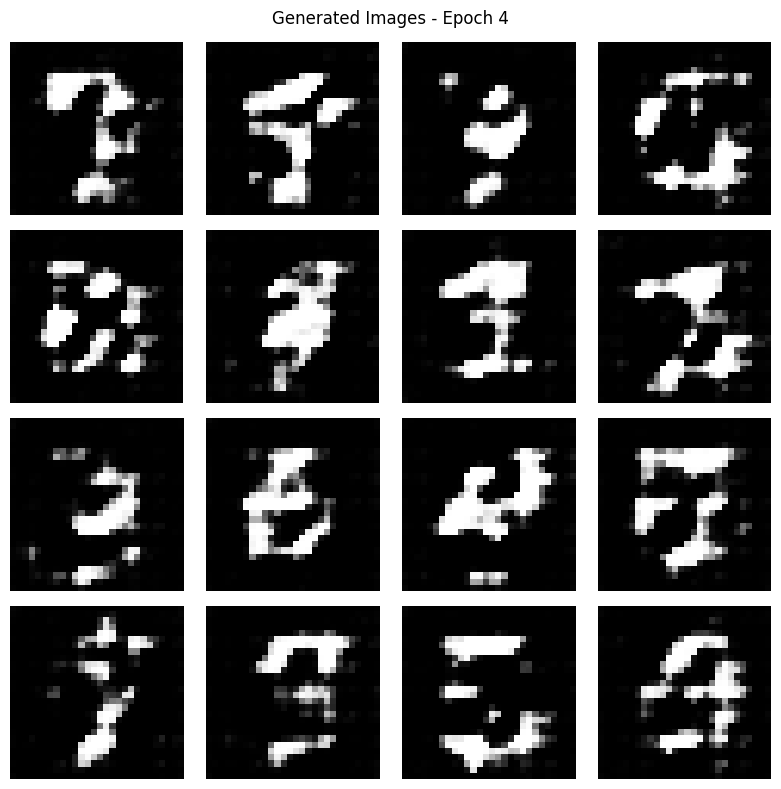

Epoch 5/5 | Steps: 156 | Generator Loss: 0.8143 | Discriminator Loss: 1.2771


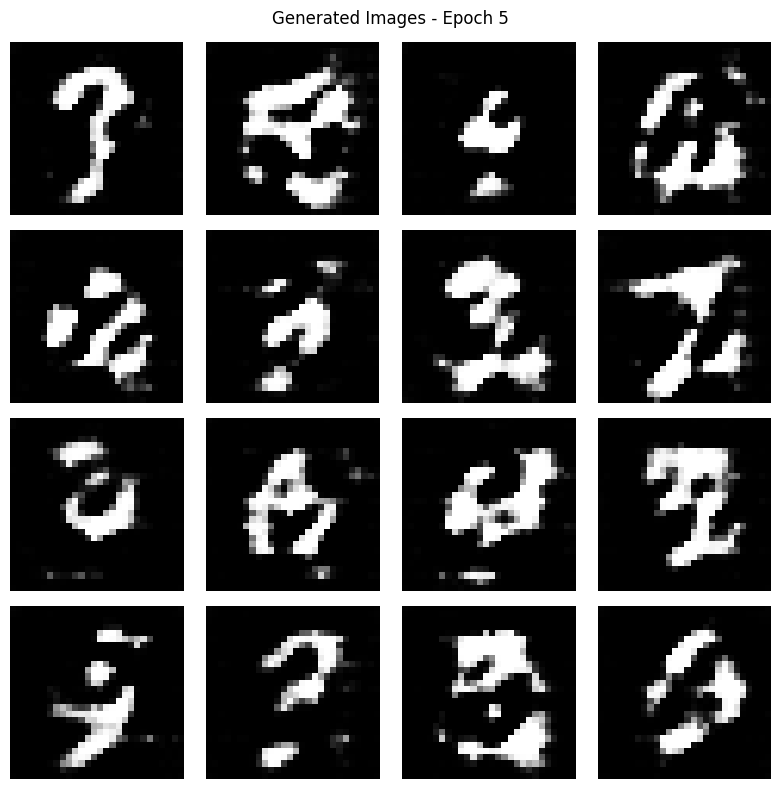

In [37]:
# Main adversarial training loop

for epoch in range(1, EPOCHS + 1):

    gen_epoch_losses = []
    disc_epoch_losses = []

    for step, image_batch in enumerate(train_dataset, start=1):
        gen_loss, disc_loss = train_step(image_batch)

        gen_epoch_losses.append(float(gen_loss))
        disc_epoch_losses.append(float(disc_loss))

    avg_gen_loss = float(np.mean(gen_epoch_losses))
    avg_disc_loss = float(np.mean(disc_epoch_losses))

    generator_losses.append(avg_gen_loss)
    discriminator_losses.append(avg_disc_loss)

    print(
        f"Epoch {epoch}/{EPOCHS} | "
        f"Steps: {steps_per_epoch} | "
        f"Generator Loss: {avg_gen_loss:.4f} | "
        f"Discriminator Loss: {avg_disc_loss:.4f}"
    )

    if epoch == 1 or epoch == EPOCHS or epoch % 2 == 0:
        show_generated_images(
            generator,
            fixed_seed,
            f"Generated Images - Epoch {epoch}"
        )


## Generator and Discriminator Loss

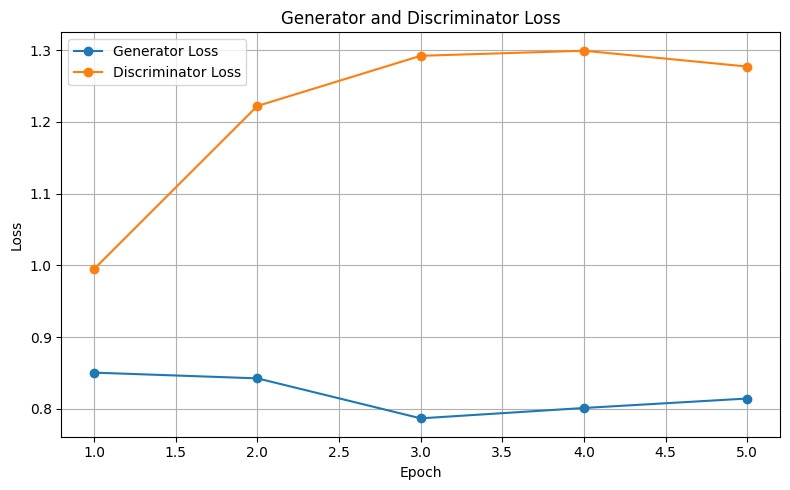

In [38]:
# Plot training losses

epoch_numbers = range(1, len(generator_losses) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epoch_numbers, generator_losses, marker="o", label="Generator Loss")
plt.plot(epoch_numbers, discriminator_losses, marker="o", label="Discriminator Loss")
plt.title("Generator and Discriminator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Real Images vs Synthetic Images

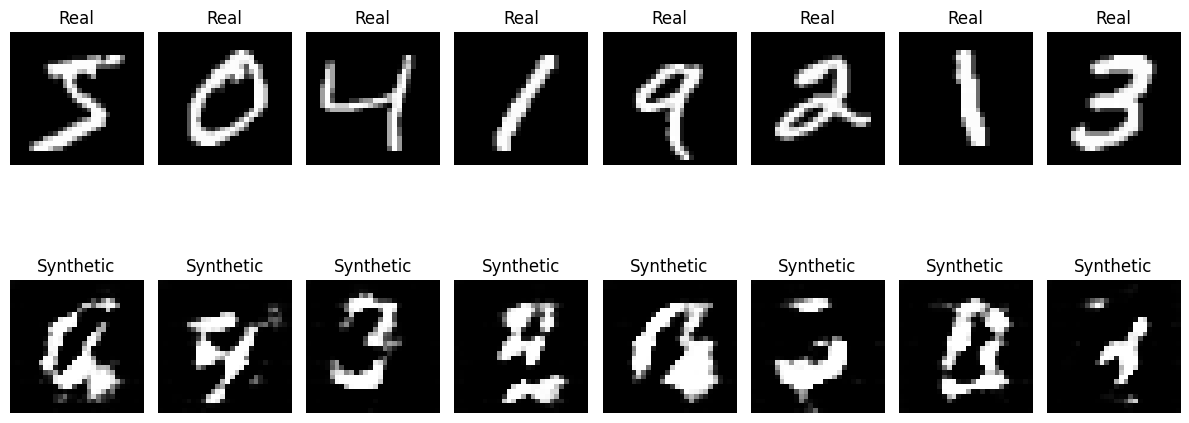

In [39]:
# Compare real and generated images

real_samples = X_images[:8]

comparison_noise = tf.random.normal(
    [8, LATENT_DIM],
    seed=SEED + 1
)

synthetic_samples = generator(
    comparison_noise,
    training=False
)

plt.figure(figsize=(12, 6))

for i in range(8):
    plt.subplot(2, 8, i + 1)
    plt.imshow(
        real_samples[i, :, :, 0] * 0.5 + 0.5,
        cmap="gray"
    )
    plt.title("Real")
    plt.axis("off")

    plt.subplot(2, 8, i + 9)
    plt.imshow(
        synthetic_samples[i, :, :, 0] * 0.5 + 0.5,
        cmap="gray"
    )
    plt.title("Synthetic")
    plt.axis("off")

plt.tight_layout()
plt.show()


## Final Synthetic Image Generation

In [40]:
# Generate final synthetic images

NUM_FINAL_IMAGES = 25

final_noise = tf.random.normal(
    [NUM_FINAL_IMAGES, LATENT_DIM],
    seed=SEED + 10
)

final_synthetic_images = generator(
    final_noise,
    training=False
).numpy()

final_synthetic_images_display = (
    final_synthetic_images * 0.5 + 0.5
)

print(
    "Final synthetic image array shape:",
    final_synthetic_images_display.shape
)


Final synthetic image array shape: (25, 28, 28, 1)


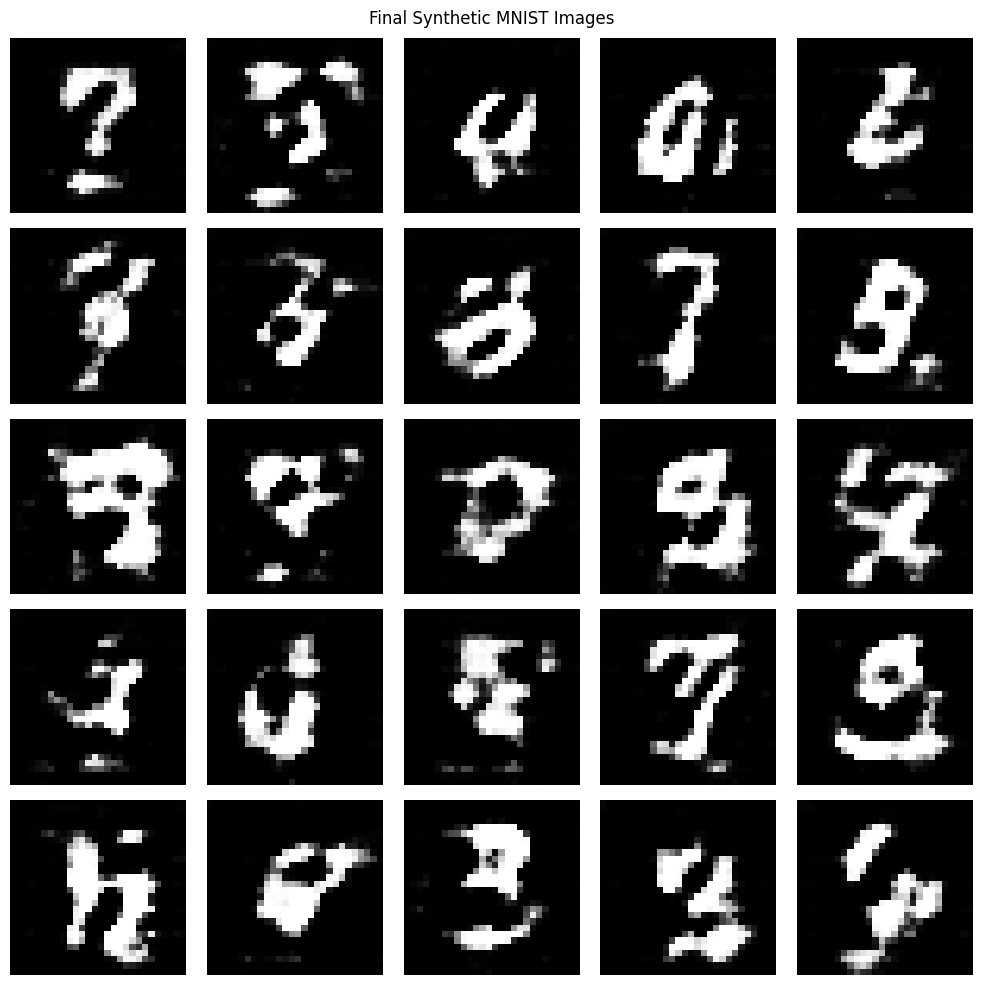

In [41]:
# Display the final generated images

plt.figure(figsize=(10, 10))

for i in range(NUM_FINAL_IMAGES):
    plt.subplot(5, 5, i + 1)
    plt.imshow(
        final_synthetic_images_display[i, :, :, 0],
        cmap="gray"
    )
    plt.axis("off")

plt.suptitle("Final Synthetic MNIST Images")
plt.tight_layout()
plt.show()


## Save Final Generated Images

In [43]:
# Save generated images in Kaggle Working

OUTPUT_DIR = "/kaggle/working/generated_mnist_images"
os.makedirs(OUTPUT_DIR, exist_ok=True)

for i, image in enumerate(final_synthetic_images_display):

    # Keep the channel dimension: (28, 28, 1)
    image_uint8 = np.clip(
        image * 255,
        0,
        255
    ).astype(np.uint8)

    tf.keras.utils.save_img(
        os.path.join(
            OUTPUT_DIR,
            f"synthetic_{i + 1:02d}.png"
        ),
        image_uint8,
        scale=False
    )

print("Images saved:", len(os.listdir(OUTPUT_DIR)))
print("Output directory:", OUTPUT_DIR)

Images saved: 25
Output directory: /kaggle/working/generated_mnist_images


## Analyze Synthetic Image Quality and Diversity

In [44]:
# Basic quantitative checks and visual observations

mean_pixel = float(final_synthetic_images_display.mean())
std_pixel = float(final_synthetic_images_display.std())

print("Mean pixel value:", round(mean_pixel, 4))
print("Pixel standard deviation:", round(std_pixel, 4))

print("\nVisual analysis:")
print("1. Generated samples should become more digit-like during training.")
print("2. Different random noise vectors should produce varied digit shapes.")
print("3. Nearly identical outputs may indicate reduced diversity or mode collapse.")


Mean pixel value: 0.1462
Pixel standard deviation: 0.3261

Visual analysis:
1. Generated samples should become more digit-like during training.
2. Different random noise vectors should produce varied digit shapes.
3. Nearly identical outputs may indicate reduced diversity or mode collapse.


## Final Model Summaries

In [45]:
print("===== GENERATOR =====")
generator.summary()

print("\n===== DISCRIMINATOR =====")
discriminator.summary()

print("\n===== GAN =====")
gan_model.summary()


===== GENERATOR =====


Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 6272)           │       627,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 6272)           │        25,088 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 14, 14, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 28, 28, 1)      │         1,601 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 858,945 (3.28 MB)

 Trainable params: 846,273 (3.23 MB)

...

Model: "GAN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ noise_input (InputLayer)        │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Generator (Sequential)          │ (None, 28, 28, 1)      │       858,945 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Discriminator (Sequential)      │ (None, 1)              │       212,865 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,071,810 (4.09 MB)

 Trainable params: 1,059,138 (4.04 MB)

 Non-trainable params: 12,672 (49.50 KB)

## Save the Trained Generator

In [46]:
# Save the trained Generator in Kaggle Working

GENERATOR_PATH = "/kaggle/working/mnist_gan_generator.keras"

generator.save(GENERATOR_PATH)

print("Generator saved to:", GENERATOR_PATH)


Generator saved to: /kaggle/working/mnist_gan_generator.keras


# RESULT

The GAN was trained on the MNIST dataset using a Generator and Discriminator. Synthetic handwritten digit images were generated from random noise and visualized at different stages of training.